## **🚗 Car Price Prediction with Machine Learning**

**Import Libraries**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Load Dataset**

In [9]:
# Check file location
print(os.listdir('/content'))
print(os.listdir('/content/sample_data'))

# Try loading
try:
    df = pd.read_csv('/content/car data.csv')
except:
    df = pd.read_csv('/content/sample_data/car data.csv')

print("Dataset Loaded Successfully ✅")
df.head()

['.config', 'sample_data']
['README.md', 'anscombe.json', 'car data.csv', 'california_housing_test.csv', 'mnist_train_small.csv', 'mnist_test.csv', 'california_housing_train.csv']
Dataset Loaded Successfully ✅


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**🔍 Dataset Preview**

In [21]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,11
1,4.75,9.54,43000,1,0,1,0,12
2,7.25,9.85,6900,2,0,1,0,8
3,2.85,4.15,5200,2,0,1,0,14
4,4.60,6.87,42450,1,0,1,0,11


**Check Columns**

In [10]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


**📊 Dataset Structure and Data Types**

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  301 non-null    float64
 1   Present_Price  301 non-null    float64
 2   Driven_kms     301 non-null    int64  
 3   Fuel_Type      301 non-null    int64  
 4   Selling_type   301 non-null    int64  
 5   Transmission   301 non-null    int64  
 6   Owner          301 non-null    int64  
 7   Car_Age        301 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 18.9 KB


**Data Preprocessing**

**Encode Categorical Features**

In [11]:
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

**Feature Engineering (Car Age)**

In [12]:
df['Car_Age'] = 2025 - df['Year']

df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

**Define Features & Target**

In [13]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

**Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**🔄 Train-Test Split Overview**

In [26]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (240, 7)
Testing data shape: (61, 7)


**Train Model**

In [15]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

**Predictions**

In [16]:
y_pred = model.predict(X_test)

**Model Evaluation**

In [17]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 0.6389196721311476
Mean Squared Error: 0.9382767457377043
R2 Score: 0.9592683769360726


**📊 Model Evaluation Results**

In [27]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.6389196721311476
MSE: 0.9382767457377043
R2 Score: 0.9592683769360726


**Bar Chart – Feature Importance**

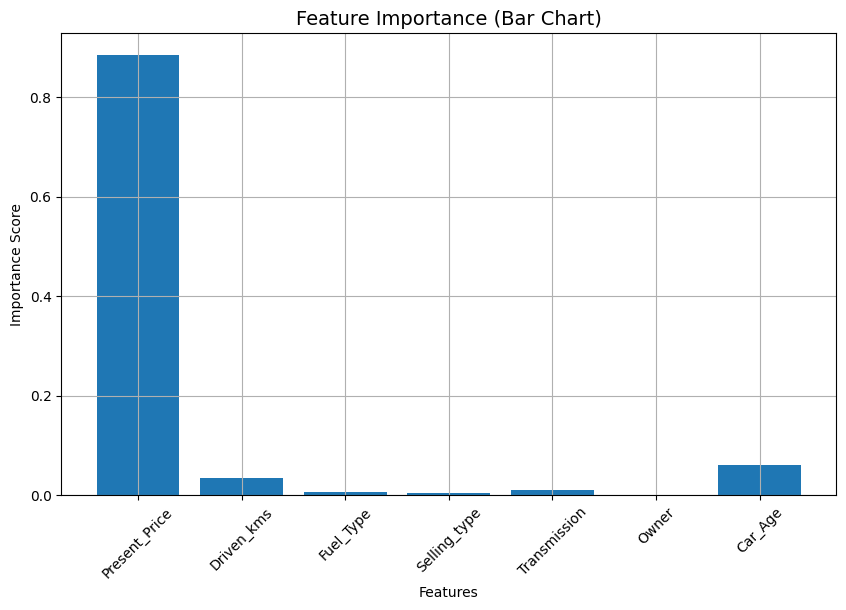

In [18]:
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance (Bar Chart)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.grid(True)
plt.show()

**Line Chart – Actual vs Predicted**

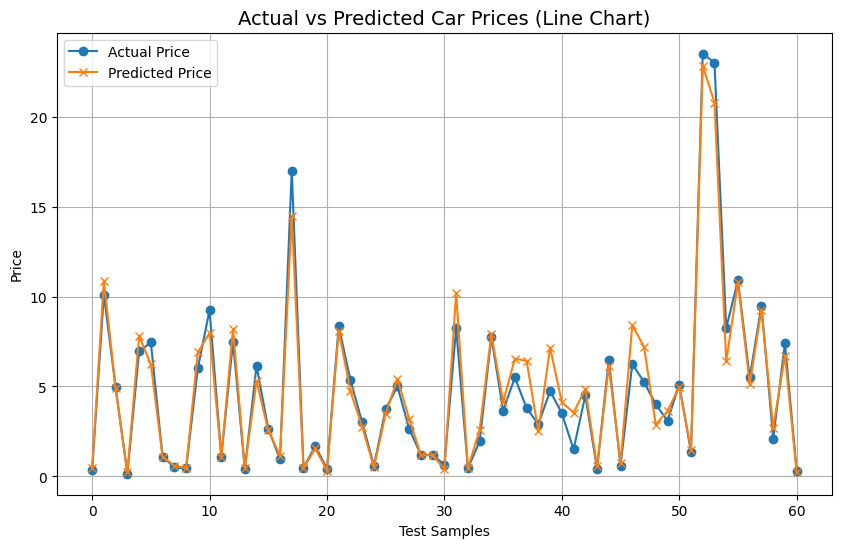

In [19]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual Price', marker='o')
plt.plot(y_pred, label='Predicted Price', marker='x')
plt.legend()
plt.title("Actual vs Predicted Car Prices (Line Chart)", fontsize=14)
plt.xlabel("Test Samples")
plt.ylabel("Price")
plt.grid(True)
plt.show()

**Scatter Plot**

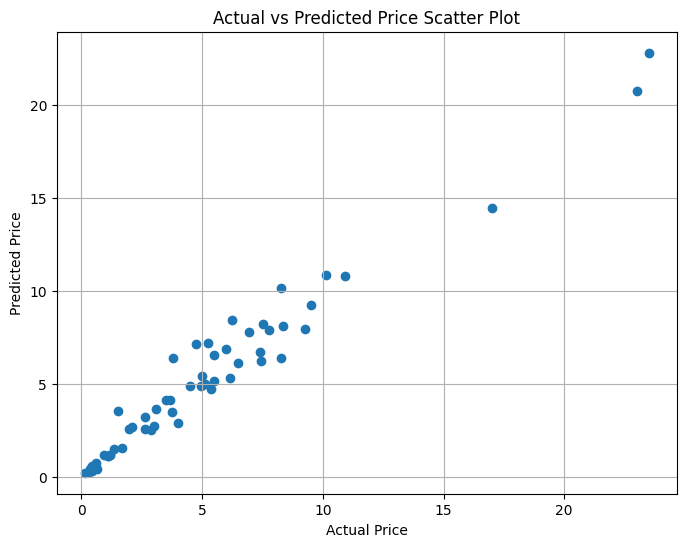

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price Scatter Plot")
plt.grid(True)
plt.show()

**Conclusion**

This project successfully developed a Machine Learning model to predict car prices using important features such as present price, fuel type, transmission, driven kilometers, and car age. After proper data preprocessing and feature engineering, a Random Forest Regression model was trained and evaluated.

The model achieved an R² score of 0.95, demonstrating excellent predictive performance with minimal error. This confirms that machine learning can provide accurate and reliable price estimation in real-world automobile markets.